In [10]:
# E Commerse Analysis

In [11]:
# Importing Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [13]:
# Loading Datasets

orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
category = pd.read_csv('product_category_name_translation.csv')

In [14]:
# Dataset Overview

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)
print("Category:", category.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Products: (32951, 9)
Reviews: (99224, 7)
Category: (71, 2)


In [15]:
# Checking Sample Data

In [16]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [17]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [18]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [19]:
# Checking Data Types

In [20]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [21]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [22]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [23]:
# Checking Missing Values

In [24]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [25]:
customers.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [26]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [27]:
reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [28]:
# Data Cleaning

In [29]:
# Removing Duplicates

orders.drop_duplicates(inplace=True)
customers.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
reviews.drop_duplicates(inplace=True)

In [30]:
# convert dates
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [31]:
#fill missing categories
products['product_category_name'] = products[
    'product_category_name'
].fillna('Unknown')

In [32]:
# Merging Datasets
# orders+customers

df = pd.merge(
    orders,
    customers,
    on='customer_id',
    how='left'
)

In [33]:
# add order items
df = pd.merge(
    df,
    order_items,
    on='order_id',
    how='left'
)

In [34]:
# add products
df = pd.merge(
    df,
    products,
    on='product_id',
    how='left'
)

In [35]:
# add category translation
df = pd.merge(
    df,
    category,
    on='product_category_name',
    how='left'
)

In [36]:
#add reviews
df = pd.merge(
    df,
    reviews[['order_id','review_score']],
    on='order_id',
    how='left'
)

In [37]:
# Verify Merge

In [38]:
df.shape

(114092, 28)

In [39]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,5.0


In [40]:
# Creating Revenue column

df['revenue'] = df['price'] + df['freight_value']

In [41]:
df[['price','freight_value','revenue']].head()

,price,freight_value,revenue
0,29.99,8.72,38.71
1,118.70,22.76,141.46
2,159.90,19.22,179.12
3,45.00,27.20,72.20
4,19.90,8.72,28.62


In [42]:
# Creating Month Column

df['month'] = df['order_purchase_timestamp'].dt.to_period('M')


In [43]:
# Highest Revenue Category

category_sales = (
    df.groupby('product_category_name_english')['revenue']
      .sum()
      .sort_values(ascending=False)
)

category_sales.head(10)


,revenue
product_category_name_english,
health_beauty,1446622.08
watches_gifts,1306761.40
bed_bath_table,1258189.51
sports_leisure,1163329.98
computers_accessories,1068070.48
furniture_decor,910683.05
housewares,781170.03
cool_stuff,721492.90
auto,687374.19


In [44]:
# Peak Sales Month

monthly_sales = (
    df.groupby('month')['revenue']
      .sum()
      .sort_values(ascending=False)
)

monthly_sales.head()

,revenue
month,
2017-11,1187779.95
2018-04,1162227.22
2018-03,1159663.98
2018-05,1150474.33
2018-01,1113929.01


In [45]:
# Best Performing Region

state_sales = (
    df.groupby('customer_state')['revenue']
      .sum()
      .sort_values(ascending=False)
)

state_sales.head(10)

,revenue
customer_state,
SP,5951489.17
RJ,2139076.28
MG,1863794.44
RS,890763.29
PR,804321.70
BA,613777.23
SC,612153.65
DF,355792.69
GO,351160.09


In [50]:
# Average Value Trend

# Calculate Monthly Revenue
monthly_revenue = (
    df.groupby('month')['revenue']
      .sum()
      .reset_index()
)

# Calculate Monthly Orders
monthly_orders = (
    df.groupby('month')['order_id']
      .nunique()
      .reset_index()
)

monthly_orders.columns = ['month', 'total_orders']

# Merge Revenue and Orders
aov_trend = pd.merge(
    monthly_revenue,
    monthly_orders,
    on='month'
)

# Calculate AOV
aov_trend['AOV'] = (
    aov_trend['revenue'] /
    aov_trend['total_orders']
)

# Display Result
aov_trend

,month,revenue,total_orders,AOV
0,2016-09,354.75,4,88.687500
1,2016-10,56989.66,324,175.894012
2,2016-12,19.62,1,19.620000
3,2017-01,138160.22,800,172.700275
4,2017-02,287698.56,1780,161.628404
5,2017-03,434044.94,2682,161.836294
6,2017-04,413387.27,2404,171.958099
7,2017-05,590516.91,3700,159.599165
8,2017-06,507123.25,3245,156.278351
9,2017-07,588966.63,4026,146.290768


In [46]:
# Review score Distribution

df['review_score'].value_counts().sort_index()

,count
review_score,
1.0,14775
2.0,3936
3.0,9476
4.0,21348
5.0,63596


In [51]:
# CHARTS

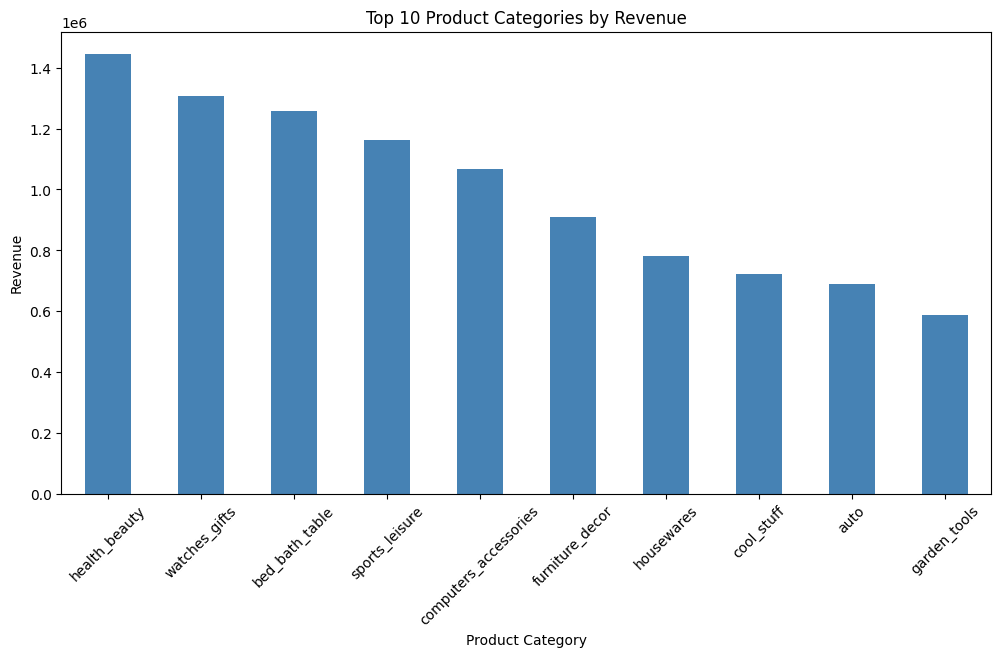

In [52]:
# Bar Chart
plt.figure(figsize=(12,6))

category_sales.head(10).plot(
    kind='bar',
    color='steelblue'
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

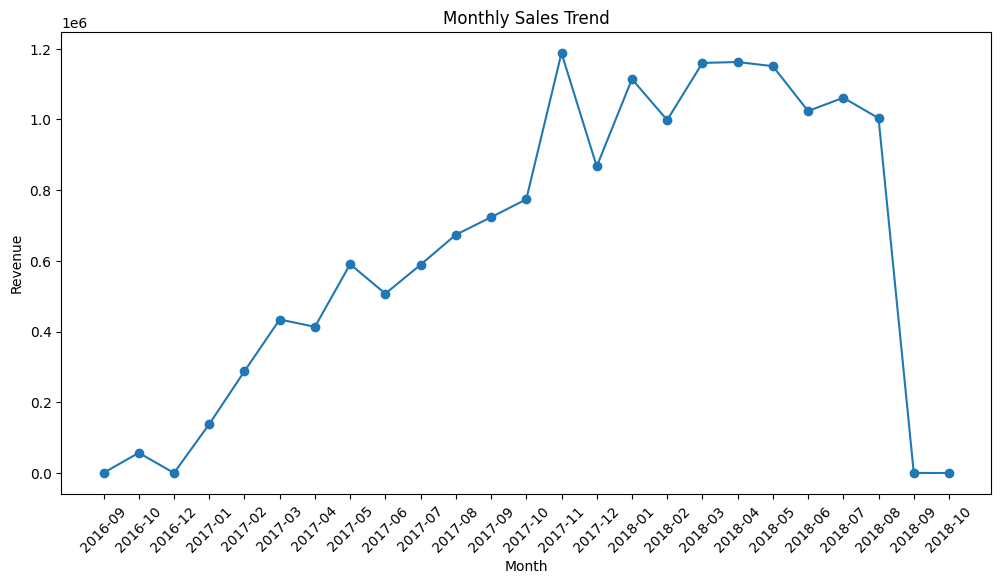

In [53]:
# Line Chart: Monthly Sales Trend

monthly_sales_sorted = monthly_sales.sort_index()

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales_sorted.index.astype(str),
    monthly_sales_sorted.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

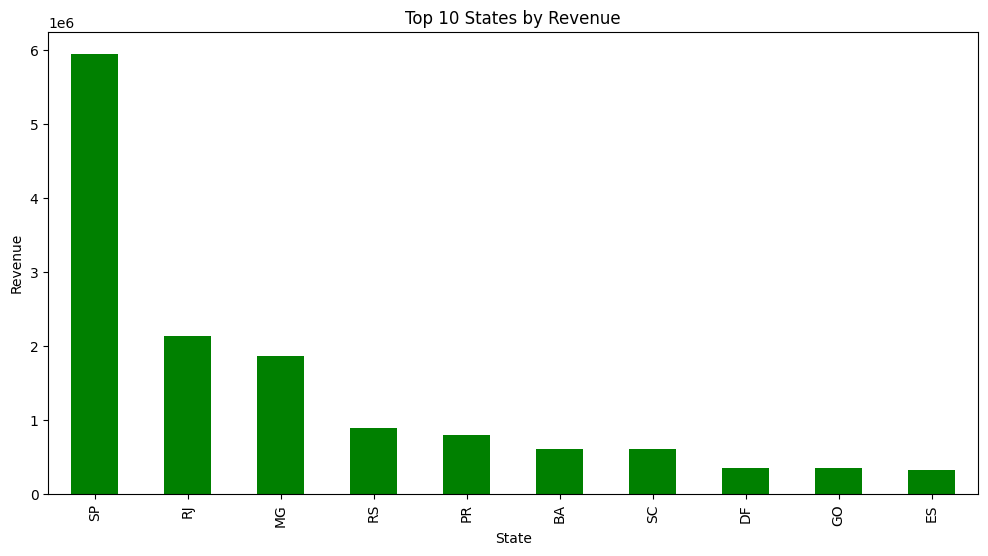

In [54]:
# Bar Chart: Regional Sales

plt.figure(figsize=(12,6))

state_sales.head(10).plot(
    kind='bar',
    color='green'
)

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

In [55]:
# Histogram: Order Value Distribution

#Creating Order value table
order_value = (
    df.groupby('order_id')['revenue']
      .sum()
      .reset_index()
)


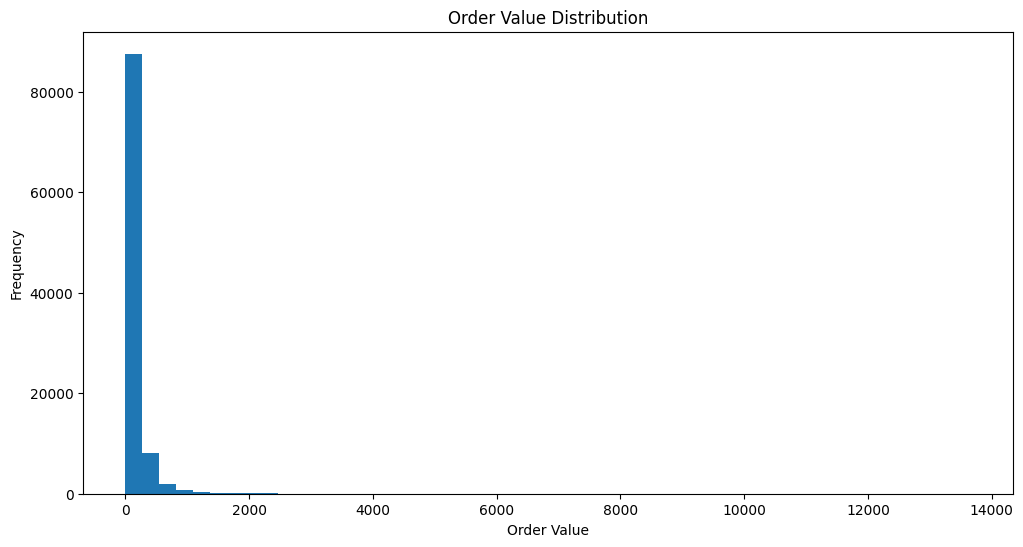

In [56]:
plt.figure(figsize=(12,6))

plt.hist(
    order_value['revenue'],
    bins=50
)

plt.title('Order Value Distribution')
plt.xlabel('Order Value')
plt.ylabel('Frequency')

plt.show()

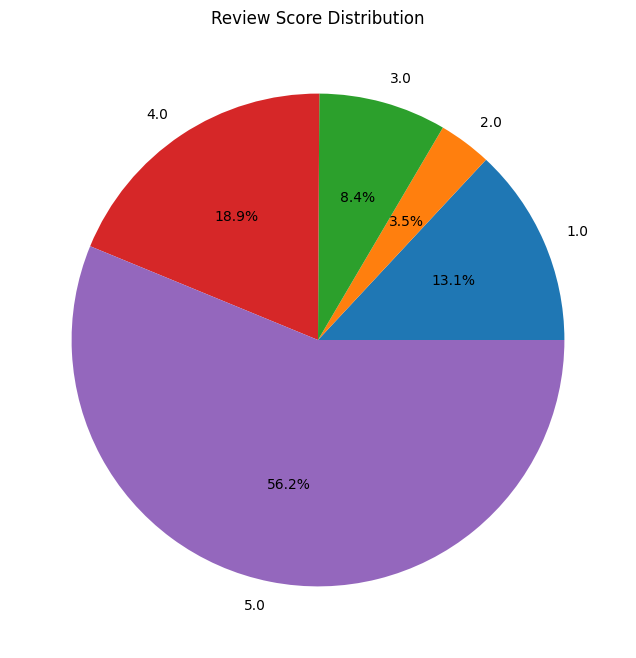

In [57]:
# Pie Chart: Review Score Distribution

review_dist = (
    df['review_score']
      .value_counts()
      .sort_index()
)

plt.figure(figsize=(8,8))

plt.pie(
    review_dist,
    labels=review_dist.index,
    autopct='%1.1f%%'
)

plt.title('Review Score Distribution')

plt.show()

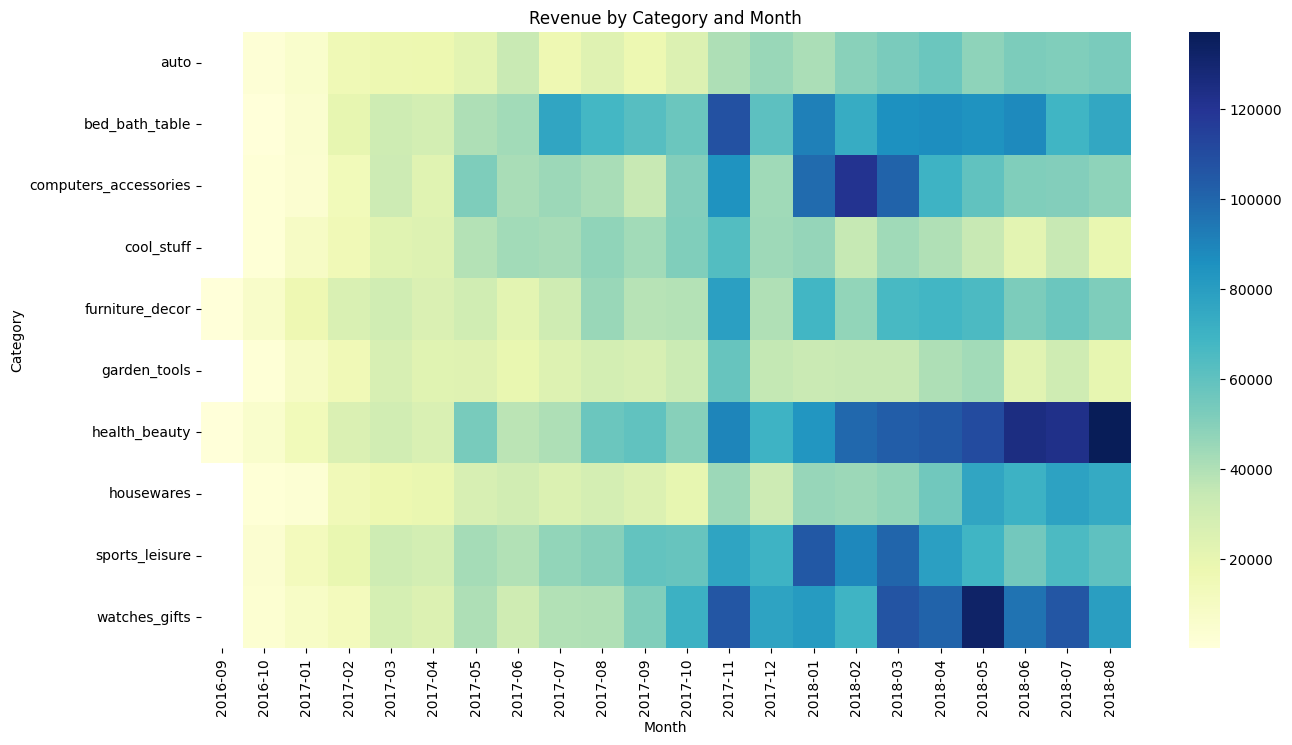

In [58]:
# Heatmap: Category vs Month

top_categories = category_sales.head(10).index

heatmap_data = pd.pivot_table(
    df[df['product_category_name_english'].isin(top_categories)],
    values='revenue',
    index='product_category_name_english',
    columns='month',
    aggfunc='sum'
)

plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title('Revenue by Category and Month')
plt.xlabel('Month')
plt.ylabel('Category')

plt.show()

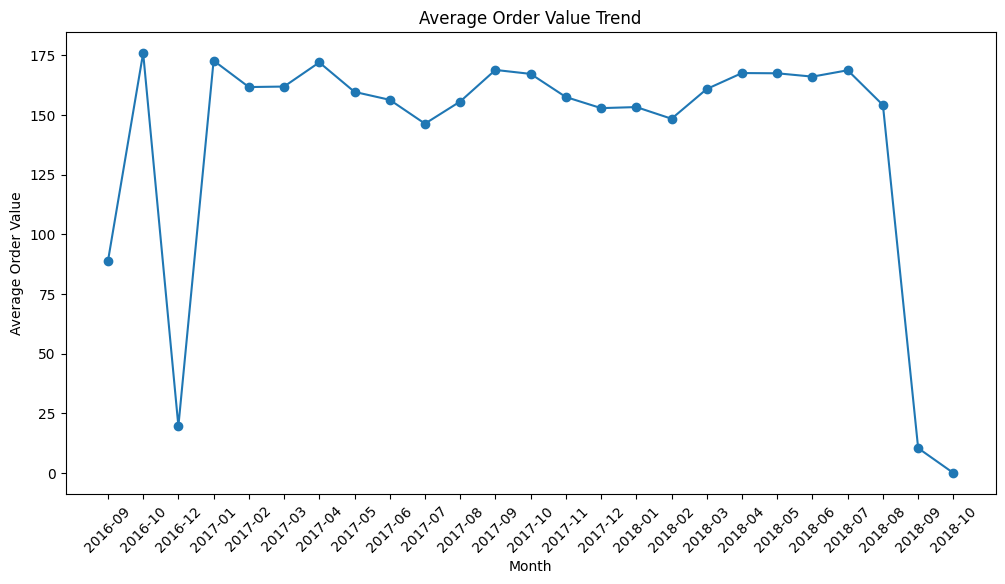

In [59]:
# Average Order Trend

plt.figure(figsize=(12,6))

plt.plot(
    aov_trend['month'].astype(str),
    aov_trend['AOV'],
    marker='o'
)

plt.title('Average Order Value Trend')
plt.xlabel('Month')
plt.ylabel('Average Order Value')

plt.xticks(rotation=45)

plt.show()

In [60]:
df.to_csv('merged_olist_dataset.csv', index=False)

In [61]:
from google.colab import files
files.download('merged_olist_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
# INSIGHTS

# Business Insights & Recommendations

## Insight 1
Health & Beauty generated the highest revenue among all product categories.

**Recommendation:** Increase inventory availability and marketing campaigns for Health & Beauty products.

## Insight 2
November 2017 recorded the highest sales revenue.

**Recommendation:** Prepare inventory and promotional campaigns before peak sales periods.

## Insight 3
São Paulo (SP) generated the highest revenue among all states.

**Recommendation:** Focus expansion and customer acquisition efforts in São Paulo.

## Insight 4
Most customers provided 5-star ratings, indicating strong customer satisfaction.

**Recommendation:** Maintain service quality and leverage positive reviews for marketing.

## Insight 5
Average Order Value remained relatively stable throughout the period.

**Recommendation:** Implement product bundles and cross-selling strategies to increase basket size.